In [1]:
import zipfile

with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/mask_dataset')

In [2]:
import os

print(os.listdir('/content/mask_dataset'))
print(os.listdir('/content/mask_dataset/data'))

['data']
['without_mask', 'with_mask']


In [3]:
dataset_path = "/content/mask_dataset/data"

In [4]:
# Import os library
import os

# Dataset path
dataset_path = "/content/mask_dataset/data"

# Count images in each class
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    print(folder, ":", len(os.listdir(folder_path)))

without_mask : 3828
with_mask : 3725


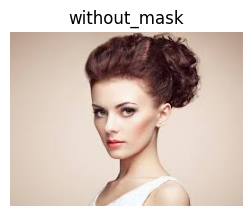

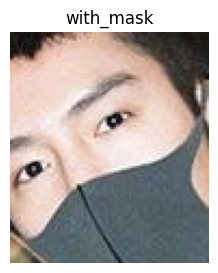

In [5]:
# Import required libraries
import matplotlib.pyplot as plt
import os
from PIL import Image

# Dataset path
dataset_path = "/content/mask_dataset/data"

# Get class names
classes = os.listdir(dataset_path)

# Display one sample image from each class
for cls in classes:

    # Select first image from the class
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]

    # Create image path
    img_path = os.path.join(dataset_path, cls, img_name)

    # Open image
    img = Image.open(img_path)

    # Display image
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    plt.show()

In [6]:
# Import os library
import os

# Dataset path
dataset_path = "/content/mask_dataset/data"

# Count images in each class
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    print(f"{folder}: {len(os.listdir(folder_path))}")

without_mask: 3828
with_mask: 3725


In [7]:
# Import TensorFlow
import tensorflow as tf

# Dataset path
dataset_path = "/content/mask_dataset/data"

# Load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32
)

Found 7553 files belonging to 2 classes.


In [8]:
# Import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preprocessing and augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation data
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [9]:
# Import required libraries
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# Load pre-trained MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze all layers of the pre-trained model
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# Create final model
mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

# Compile model
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Train MobileNetV2 model
history_mobilenet = mobilenet_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
 60/189 ━━━━━━━━━━━━━━━━━━━━ 3:15 2s/step - accuracy: 0.8778 - loss: 0.2685

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.9724 - loss: 0.0660 - val_accuracy: 0.9576 - val_loss: 0.1278
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.9939 - loss: 0.0184 - val_accuracy: 0.9887 - val_loss: 0.0369
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.9960 - loss: 0.0109 - val_accuracy: 0.9901 - val_loss: 0.0346
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.9988 - loss: 0.0046 - val_accuracy: 0.9834 - val_loss: 0.0646
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.9987 - loss: 0.0050 - val_accuracy: 0.9914 - val_loss: 0.0316
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.9990 - loss: 0.0026 - val_accuracy: 0.9887 - val_loss: 0.0426
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9907 - val_loss: 0.0352
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 1.0000 - loss: 3.7856e-04 - val_accuracy: 0

In [11]:
# Evaluate MobileNetV2 model
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(val_data)

print("Validation Accuracy:", mobilenet_accuracy)
print("Validation Loss:", mobilenet_loss)

48/48 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9887 - loss: 0.0428
Validation Accuracy: 0.9887416958808899
Validation Loss: 0.04275016114115715


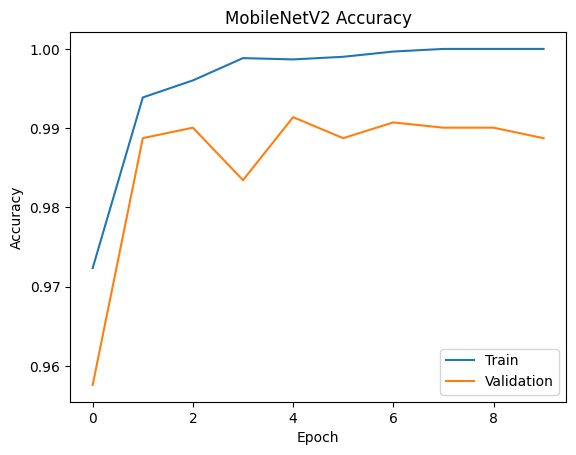

In [14]:
import matplotlib.pyplot as plt

# Plot MobileNetV2 accuracy
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

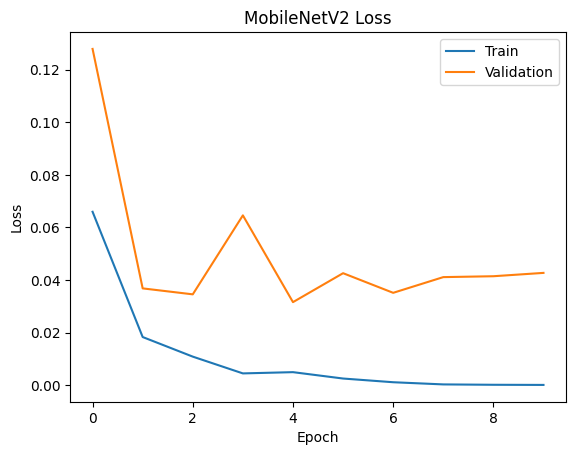

In [15]:
# Plot MobileNetV2 loss
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])

plt.title('MobileNetV2 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

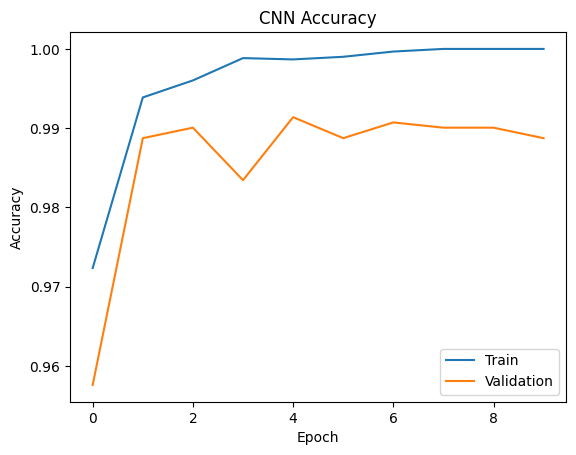

In [16]:
# Import plotting library
import matplotlib.pyplot as plt

# Plot CNN accuracy
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])

plt.title('CNN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
# Plot CNN loss
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])

plt.title('CNN Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()